Task 1: Apply Principal Component Analysis (PCA) for feature extraction and dimensionality reduction

Subtask 1.1: Data Acquisition and Feature Standardization

In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
from sklearn.datasets import load_iris

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
raw_iris = load_iris()

In [8]:
features = raw_iris.feature_names

In [9]:
X_raw = raw_iris.data

In [10]:
y_true = raw_iris.target

In [11]:
scaler = StandardScaler()

In [12]:
X_scaled = scaler.fit_transform(X_raw)

In [13]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)

In [14]:
iris_df['species_id'] = y_true

In [15]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [16]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)

In [17]:
print("Standardized dataset dimensions:", X_scaled.shape)

Standardized dataset dimensions: (150, 4)


In [18]:
print("\nFirst 3 rows of standardized dataset:")


First 3 rows of standardized dataset:


In [19]:
print(iris_df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


Subtask 1.2: Covariance Matrix and Eigenvalue Decomposition

In [20]:
cov_matrix = np.cov(X_scaled.T)

In [21]:
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [22]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [23]:
print("\nEigenvalues (Variance components):\n", eigenvalues)


Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [24]:
print("\nEigenvectors (Principal Axes):\n", eigenvectors)


Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


Subtask 1.3: Implementing Dimensionality Reduction via PCA

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca_model = PCA(n_components=2, random_state=42)

In [27]:
X_pca = pca_model.fit_transform(X_scaled)

In [28]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])

In [29]:
pca_df['species_name'] = iris_df['species_name']

In [30]:
print("Transformed PCA space dimensions:", X_pca.shape)

Transformed PCA space dimensions: (150, 2)


In [31]:
print("\nFirst 3 projected coordinates:")


First 3 projected coordinates:


In [32]:
print(pca_df.head(3))

       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


Subtask 1.4: Visualizing the 2D PCA Feature Space

In [33]:
import matplotlib.pyplot as plt

In [34]:
import seaborn as sns

In [35]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

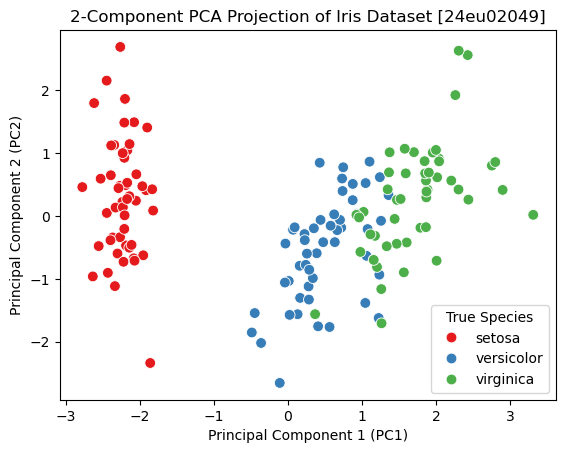

In [36]:
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("2-Component PCA Projection of Iris Dataset [24eu02049]")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()


Subtask 1.5: Analyzing Explained Variance Ratio

In [37]:
explained_variance = pca_model.explained_variance_ratio_

In [38]:
cumulative_variance = np.sum(explained_variance)

In [39]:
print("Explained Variance per Component:")

Explained Variance per Component:


In [40]:
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

  PC1: 72.96%
  PC2: 22.85%


In [41]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


In [42]:
import numpy as np

In [43]:
import pandas as pd

In [44]:
import matplotlib.pyplot as plt

In [45]:
from sklearn.datasets import load_iris

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
from sklearn.decomposition import PCA

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [51]:
iris = load_iris()

In [52]:
X = iris.data

In [53]:
y = iris.target

In [54]:
feature_names = iris.feature_names

In [55]:
target_names = iris.target_names

In [56]:
print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [57]:
print("Features:", feature_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [58]:
print("Classes:", target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [60]:
scaler = StandardScaler()

In [61]:
X_train_scaled = scaler.fit_transform(X_train)

In [62]:
X_test_scaled = scaler.transform(X_test)

In [63]:
print("CLASSIFICATION WITHOUT PCA")

CLASSIFICATION WITHOUT PCA


In [64]:
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [65]:
model_without_pca.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [66]:
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

In [67]:
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

In [68]:
print("Accuracy without PCA:",
      accuracy_without_pca)

Accuracy without PCA: 0.9333333333333333


In [69]:
print("\nClassification Report:")


Classification Report:


In [70]:
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [71]:
print("CLASSIFICATION WITH PCA")

CLASSIFICATION WITH PCA


In [72]:
pca = PCA(
    n_components=2
)

In [73]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [74]:
X_test_pca = pca.transform(
    X_test_scaled
)


In [75]:
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

Explained Variance Ratio: [0.72677234 0.23066667]


In [76]:
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

Total Explained Variance: 0.9574390106545367


In [77]:
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [78]:
model_with_pca.fit(
    X_train_pca,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [79]:
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

In [80]:
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

In [81]:
print("Accuracy with PCA:",
      accuracy_with_pca)

Accuracy with PCA: 0.9


In [82]:
print("\nClassification Report:")


Classification Report:


In [83]:
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [84]:
print("COMPARISON")

COMPARISON


In [85]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

In [86]:
print(comparison)

        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


In [87]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

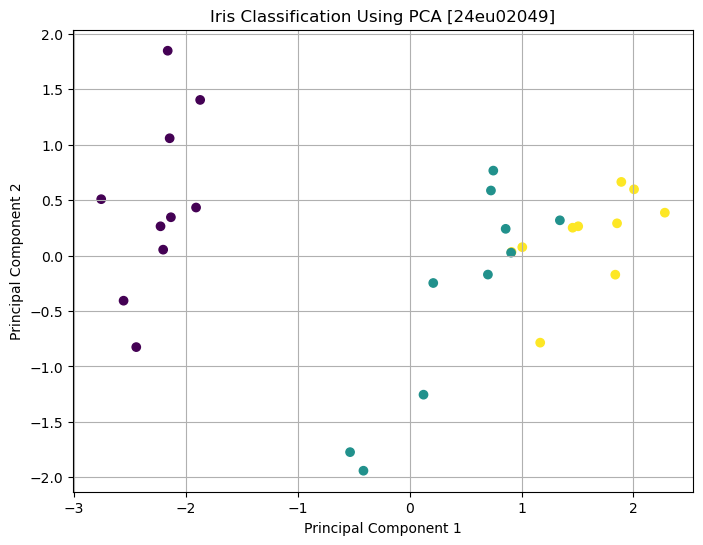

In [88]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Classification Using PCA [24eu02049]")
plt.grid()
plt.show()

Task 2: Design clustering models using K-Means clustering for pattern discovery and data grouping

Subtask 2.1: Determining Clusters via the Elbow Method (WCSS)

In [89]:
import warnings

In [90]:
warnings.filterwarnings("ignore")

In [91]:
from sklearn.cluster import KMeans

In [92]:
import matplotlib.pyplot as plt

In [93]:
wcss = []

In [94]:
k_range = range(1, 11)

In [95]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled) 
    wcss.append(kmeans.inertia_)

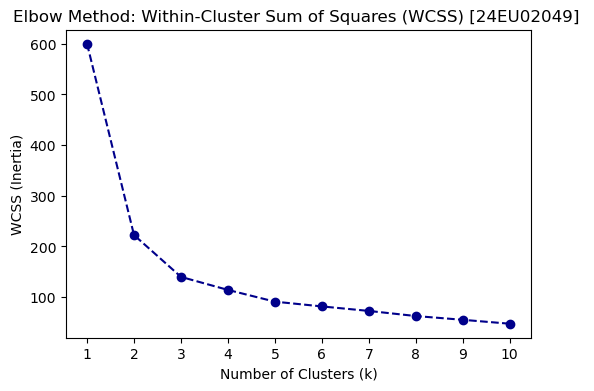

In [96]:
# Plot the Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS) [24EU02049] ")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()

Subtask 2.2: Validating Optimal Clusters with Silhouette Analysis

In [97]:
from sklearn.metrics import silhouette_score

In [98]:
silhouette_scores = []

In [99]:
k_eval = range(2, 6)

In [100]:
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)


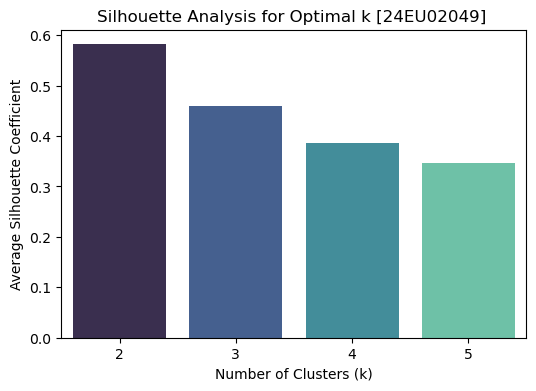

In [101]:
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("Silhouette Analysis for Optimal k [24EU02049] ")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()

In [102]:
best_k = k_eval[np.argmax(silhouette_scores)]

In [103]:
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")

k = 2 yielded the highest silhouette coefficient (0.5818).


Subtask 2.3: Implementing K-Means Clustering on the Raw Feature Space

In [104]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [105]:
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

In [106]:
iris_df['cluster_raw'] = kmeans_raw_labels

In [107]:
print("K-Means clustering complete. First 5 sample allocations:")

K-Means clustering complete. First 5 sample allocations:


In [108]:
print(iris_df[['species_name', 'cluster_raw']].head(5))

  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


Subtask 2.4: Extracting and Inspecting Cluster Centroids

In [109]:
raw_centroids_scaled = kmeans_raw.cluster_centers_

In [110]:
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

In [111]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)

In [112]:
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

In [113]:
print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")

--- Estimated Cluster Centroids (Original Physical Units - cm) ---


In [114]:
print(centroids_df)

           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.799612          2.653772           4.382414   
Cluster_1           4.992043          3.429444           1.471740   
Cluster_2           6.792945          3.087827           5.524364   

           petal width (cm)  
Cluster_0          1.418814  
Cluster_1          0.251935  
Cluster_2          1.977790  


Subtask 2.5: Visualizing Raw Clusters and Centroids

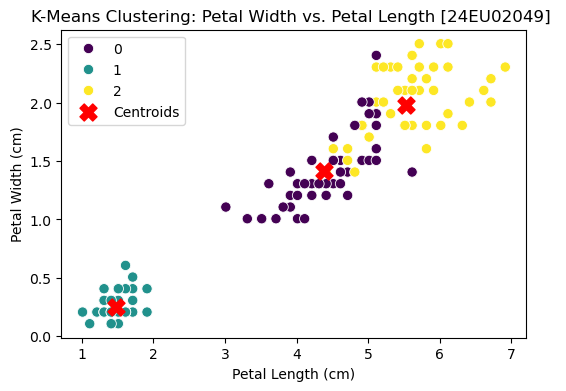

In [115]:
plt.figure(figsize=(6, 4))

# Convert standardized centroids to original units for plotting
raw_data = scaler.inverse_transform(X_scaled)

# Plot the continuous data points colored by cluster assignment
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

# Plot the calculated centroids on the same canvas
plt.scatter(
    raw_centroids_physical[:, 2], 
    raw_centroids_physical[:, 3], 
    color='red', 
    marker='X', 
    s=150, 
    label='Centroids'
)

plt.title("K-Means Clustering: Petal Width vs. Petal Length [24EU02049] ")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()


Task 3: Analyze clustering performance and compare transformed feature spaces for improved data interpretation

Subtask 3.1: K-Means Clustering in the PCA-Reduced Space

In [116]:
import warnings

In [117]:
warnings.filterwarnings("ignore")

In [118]:
from sklearn.cluster import KMeans

In [119]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [120]:
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

In [121]:
iris_df['cluster_pca'] = kmeans_pca_labels

In [122]:
print("PCA space K-Means clustering completed successfully.")

PCA space K-Means clustering completed successfully.


Subtask 3.2: Internal Validation Metrics (Silhouette and Calinski-Harabasz Scores)

In [123]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [124]:
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)

In [125]:
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)

In [126]:
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)

In [127]:
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)

In [128]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")

--- Internal Validation (Unsupervised Quality Metrics) ---


In [129]:
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")

Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90


In [130]:
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")


PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


Subtask 3.3: Faceted Visual Comparison: K-Means Clusters vs. True Species

In [131]:
import matplotlib.pyplot as plt

In [132]:
import seaborn as sns

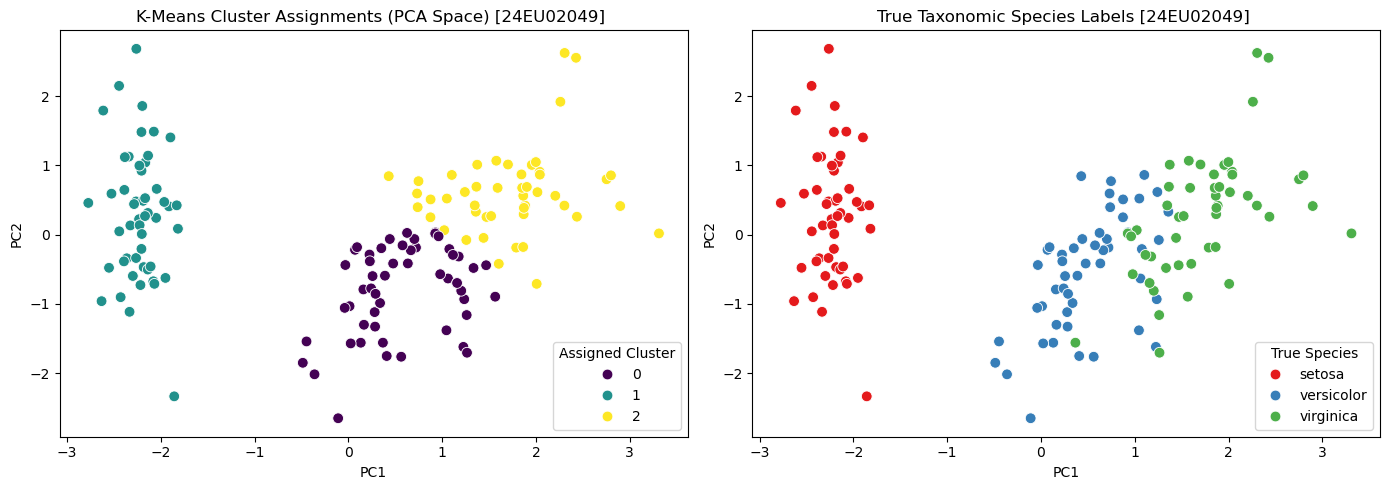

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PCA Coordinates colored by K-Means cluster allocations
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels, 
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("K-Means Cluster Assignments (PCA Space) [24EU02049] ")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name', 
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("True Taxonomic Species Labels [24EU02049] ")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()